# SOM-VAE для классификации спутниковых изображений EuroSAT

## Импорты и загрузка данных

In [1]:
import optuna

# Основные библиотеки
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch import nn
from torch.functional import F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# Обработка данных
import polars as pl
import os
from PIL import Image
from pathlib import Path

import random
# Метрики
from sklearn.metrics import normalized_mutual_info_score

# Прогресс-бары
from tqdm.notebook import tqdm

# Загрузка датасетов
import kagglehub

## Загрузка датасета EuroSAT

In [2]:
# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)
img_path = os.path.join(path, "EuroSAT")

Path to dataset files: /home/mihalko711/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


## Создание Dataset класса

In [3]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None, filt_class=None, return_label=False):
        self.df = pl.read_csv(csv_path).drop(pl.read_csv(csv_path).columns[0])
        self.image_root = Path(image_root)
        self.transform = transform  # ← внешний трансформ
        self.return_label = return_label

        if filt_class is not None:
            self.df = self.df.filter(pl.col("Label") == filt_class)
            
    def __len__(self):
        return self.df.height

    def __getitem__(self, idx):
        row = self.df.row(idx, named=True)

        img_path = self.image_root / row["Filename"]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)  # ← применяем внешний трансформ

        if self.return_label:
            return image, row["Label"], row["ClassName"]

        return image

## Создание датасетов

In [4]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomChoice([
        T.Lambda(lambda x: x),                          # 0°
        T.Lambda(lambda x: x.rotate(90, expand=False)),   # 90°
        T.Lambda(lambda x: x.rotate(180, expand=False)),  # 180°
        T.Lambda(lambda x: x.rotate(270, expand=False)),  # 270°
    ]),
    T.ColorJitter(brightness=0.05, contrast=0.05),
    T.RandomApply([T.GaussianBlur(3, (0.1, 0.3))], p=0.05),
    T.Resize((64, 64)),  # Для надёжности (изображения EuroSAT уже 64×64)
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1, 1]
])

val_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Создание датасетов
train_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "train.csv"),
    image_root=img_path,
    transform=train_transform,
    return_label=True
)

val_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "validation.csv"),
    image_root=img_path,
    transform=val_transform,
    return_label=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 18900
Validation dataset size: 5400


## Демонстрация изображений

Image shape: torch.Size([3, 64, 64])
Label: 4 (Industrial)


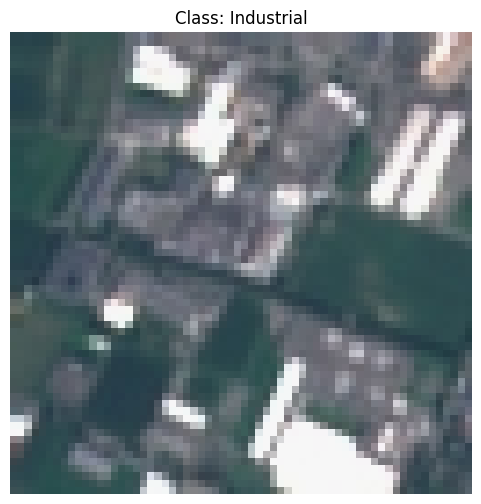

In [5]:
# Показываем случайное изображение из тренировочного датасета
idx = np.random.randint(len(train_dataset))
x, label, name = train_dataset[idx]

print(f"Image shape: {x.shape}")
print(f"Label: {label} ({name})")

# Денормализация для отображения
img_display = x.permute(1, 2, 0) * 0.5 + 0.5
plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Class: {name}")
plt.axis('off')
plt.show()

## Просмотр примеров по классам

Classes in dataset: shape: (10,)
Series: 'ClassName' [str]
[
	"HerbaceousVegetation"
	"Pasture"
	"Industrial"
	"River"
	"PermanentCrop"
	"Forest"
	"Highway"
	"Residential"
	"SeaLake"
	"AnnualCrop"
]


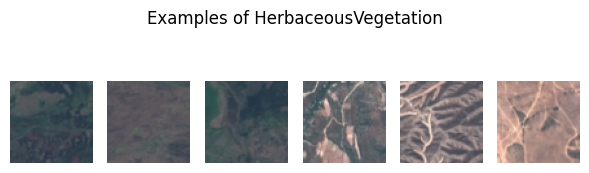

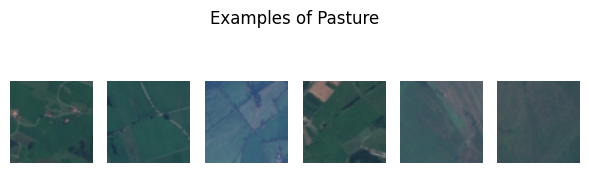

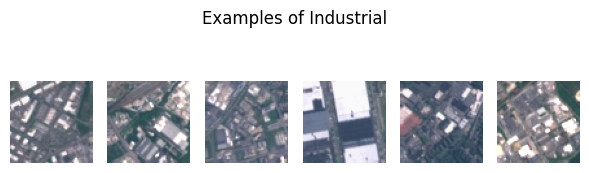

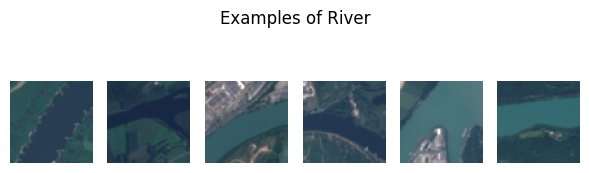

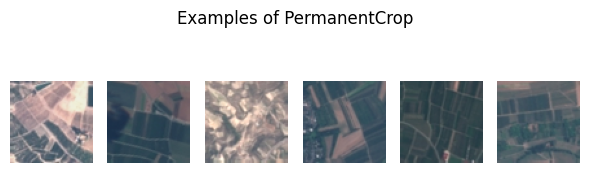

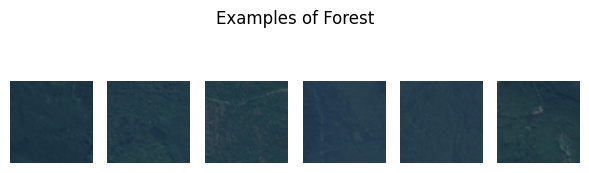

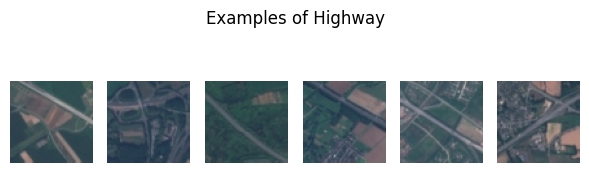

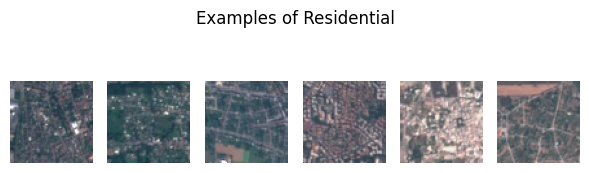

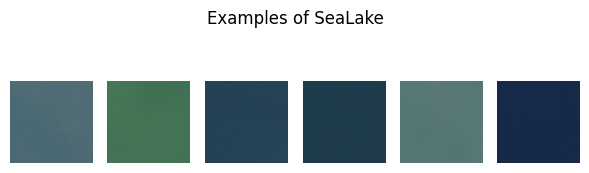

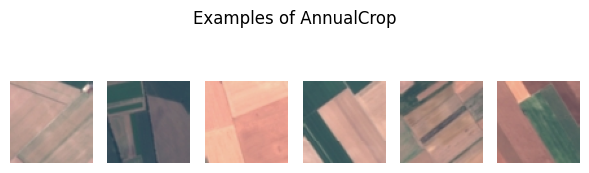

In [6]:
def plot_n_rand_class(dataset, class_name, n=8):
    """Показывает n случайных изображений указанного класса"""
    idxs = dataset.df \
        .with_columns(
            pl.arange(0, pl.len()).alias("idx")
        ) \
        .filter(
            pl.col("ClassName") == class_name
        ) \
        .select("idx").to_numpy().ravel()
    
    n_rand_idxs = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)
    
    fig = plt.figure(figsize=(n, 2))
    fig.suptitle(f"Examples of {class_name}")
    for i, idx in enumerate(n_rand_idxs):
        x, label, class_name = dataset[idx]
        ax = fig.add_subplot(1, len(n_rand_idxs), i + 1)
        ax.imshow(x.permute(1, 2, 0) * 0.5 + 0.5)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Показываем примеры для каждого класса
unique_classes = train_dataset.df["ClassName"].unique()
print(f"Classes in dataset: {unique_classes}")

for class_name in unique_classes:
    plot_n_rand_class(train_dataset, class_name, n=6)

## Статистика датасета

Class distribution:
shape: (10, 2)
┌──────────────────────┬───────┐
│ ClassName            ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ AnnualCrop           ┆ 2100  │
│ Forest               ┆ 2100  │
│ HerbaceousVegetation ┆ 2100  │
│ Highway              ┆ 1750  │
│ Industrial           ┆ 1750  │
│ Pasture              ┆ 1400  │
│ PermanentCrop        ┆ 1750  │
│ Residential          ┆ 2100  │
│ River                ┆ 1750  │
│ SeaLake              ┆ 2100  │
└──────────────────────┴───────┘


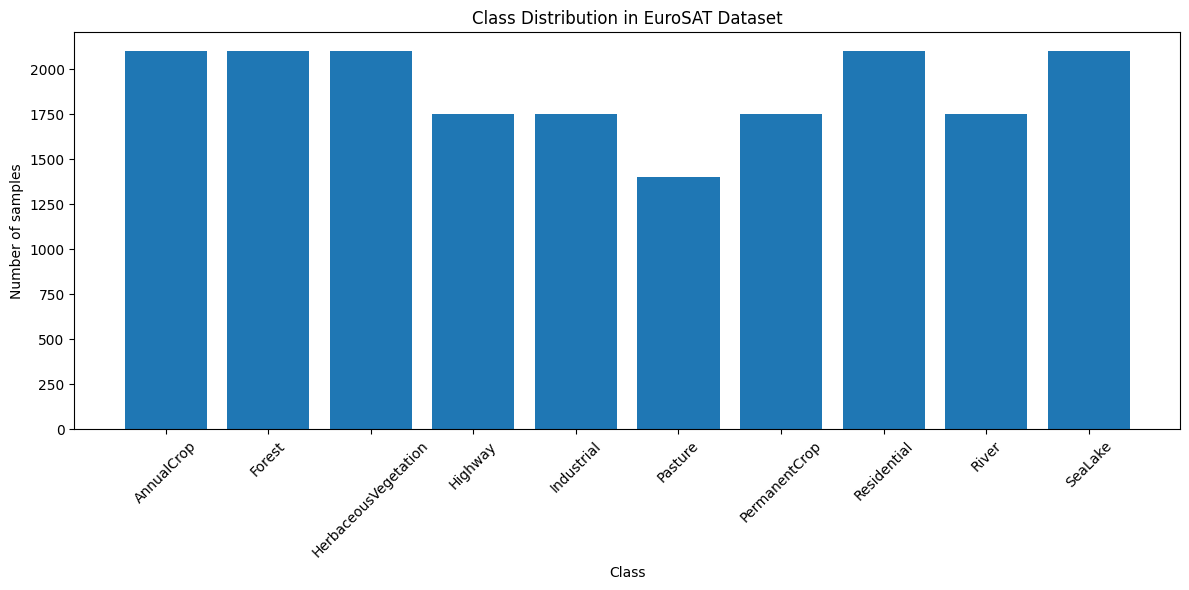

In [7]:
# Анализ распределения классов
class_counts = train_dataset.df["ClassName"].value_counts().sort("ClassName")
print("Class distribution:")
print(class_counts)

# Визуализация распределения
plt.figure(figsize=(12, 6))
plt.bar(class_counts["ClassName"], class_counts["count"])
plt.title("Class Distribution in EuroSAT Dataset")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Классы моделек

In [11]:
class GlobalSOMLayer(nn.Module):
    def __init__(self, grid_h, grid_w, channels, latent_h, latent_w):
        super().__init__()
        self.grid_h, self.grid_w = grid_h, grid_w
        self.c, self.h, self.w = channels, latent_h, latent_w
        self.template_dim = channels * latent_h * latent_w
        
        self.embeddings = nn.Parameter(torch.randn(grid_h * grid_w, self.template_dim) * 1e-2)

        indices = torch.arange(grid_h * grid_w)
        # Соседи: left, up, right, down
        ln = torch.where(indices % grid_w == 0, -1, indices - 1)
        rn = torch.where(indices % grid_w == grid_w - 1, -1, indices + 1)
        un = torch.where(indices < grid_w, -1, indices - grid_w)
        dn = torch.where(indices >= (grid_h - 1) * grid_w, -1, indices + grid_w)
        
        self.register_buffer('neighbors_indices', torch.stack([ln, un, rn, dn], dim=1))
        self.register_buffer('valid_mask', (self.neighbors_indices != -1).float())
        
    def get_neighbors(self, indices):
        return self.neighbors_indices[indices]

    def forward(self, z_e, stochastic=True):
        batch_size = z_e.size(0)
        z_e_flat = z_e.view(batch_size, -1)
        
        # Расстояния до всех узлов
        distances = torch.cdist(z_e_flat, self.embeddings) # [B, N]
        bmu_indices = torch.argmin(distances, dim=1)
        
        if not stochastic:
            z_q_flat = self.embeddings[bmu_indices]
        else:
            # Получаем индексы и маски соседей для батча
            n_idx = self.get_neighbors(bmu_indices) # [B, 4]
            mask = self.valid_mask[bmu_indices]     # [B, 4]
            
            # Расстояния до соседей (используем clamp, чтобы не выйти за границы при индексе -1)
            dist_n = torch.gather(distances, 1, n_idx.clamp(min=0)) * mask
            
            # Веса соседей: (1 - d_i / d_max)
            d_max = dist_n.max(dim=1, keepdim=True)[0]
            w_n = (1.0 - dist_n / (d_max + 1e-8)) * mask
            
            # Вес победителя всегда 1.0
            w_bmu = torch.ones(batch_size, 1, device=z_e.device)
            
            # Собираем все веса и эмбеддинги
            all_w = torch.cat([w_bmu, w_n], dim=1) # [B, 5]
            all_w = all_w / all_w.sum(dim=1, keepdim=True)
            
            emb_bmu = self.embeddings[bmu_indices].unsqueeze(1)    # [B, 1, D]
            emb_n = self.embeddings[n_idx.clamp(min=0)]           # [B, 4, D]
            all_emb = torch.cat([emb_bmu, emb_n], dim=1)           # [B, 5, D]
            
            # Итоговый латент как взвешенная сумма
            z_q_flat = (all_emb * all_w.unsqueeze(-1)).sum(dim=1)
        
        return (
            self.embeddings[bmu_indices].view(batch_size, self.c, self.h, self.w),
            z_q_flat.view(batch_size, self.c, self.h, self.w),
            bmu_indices
        )

    def calc_activations(self, z_e):
        distances = torch.cdist(z_e.view(z_e.size(0), -1), self.embeddings)
        return 1.0 / (distances + 1e-8)

In [12]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class EuroSAT_GlobalSOM_Deep(nn.Module):
    def __init__(self, in_channels=3, grid_size=(16, 16), latent_dim=(32, 8, 8), num_classes=10):
        super().__init__()
        c_l, h_l, w_l = latent_dim

        # ---------------------
        # 1. ENCODER (64x64 -> 8x8)
        # ---------------------
        self.encoder = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # feature refinement at 8x8
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # channel projection to latent
            nn.Conv2d(128, c_l, 1)
        )

        # ---------------------
        # 2. SOM LAYER
        # ---------------------
        self.som = GlobalSOMLayer(grid_size[0], grid_size[1], c_l, h_l, w_l)

        # ---------------------
        # 3. DECODER (8x8 -> 64x64)
        # ---------------------
        self.decoder = nn.Sequential(
            # latent refinement — ОЧЕНЬ правильно, что он у тебя есть
            nn.Conv2d(c_l, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(128),
        
            # 8 -> 16
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(128),
        
            # 16 -> 32
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(64),
        
            # 32 -> 64
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(32),
        
            nn.Conv2d(32, in_channels, 3, padding=1),
            nn.Tanh()
        )



    def forward(self, x):
        z_e = self.encoder(x)
        z_q, z_q_sample, indices = self.som(z_e)
        x_hat_e = self.decoder(z_e)
        x_hat_q = self.decoder(z_q_sample)
        return x_hat_e, x_hat_q, z_e, z_q, indices

    def decode(self, z):
        return self.decoder(z)


## Loss Function

In [13]:
def som_vae_loss(
    x, x_hat_e, x_hat_q, z_e, z_q, indices, som_layer,
    alpha=1.0, beta=1.0
):
    # -------------------------
    # 1. Reconstruction loss (L2)
    # -------------------------
    l_rec_e = F.mse_loss(x_hat_e, x)
    l_rec_q = F.mse_loss(x_hat_q, x)
    l_reconstruction = l_rec_q + 0.25 * l_rec_e

    # -------------------------
    # 3. Commitment loss (L2)
    # -------------------------
    l_commitment = F.mse_loss(z_e, z_q)

    # -------------------------
    # 4. SOM neighbor loss (L2)
    # -------------------------
    neighbor_indices = som_layer.get_neighbors(indices)
    neighbors = som_layer.embeddings[neighbor_indices]
    z_e_target = z_e.detach().view(z_e.shape[0], -1).unsqueeze(1)
    l_som = torch.mean((neighbors - z_e_target) ** 2)

    # -------------------------
    # 5. Total loss
    # -------------------------
    total_loss = (
        l_reconstruction
        + alpha * l_commitment
        + beta * l_som
    )

    return (
        total_loss,
        l_reconstruction,
        l_commitment,
        l_som
    )

## Training Functions

### Map init func

In [14]:
def restart_som_with_data(model, train_loader, device):
    """
    Инициализация весов SOM реальными данными из первого батча
    """
    model.eval()
    with torch.no_grad():
        # Берем один батч
        images, _, _ = next(iter(train_loader))
        z_e = model.encoder(images.to(device)) # [B, C, H, W]
        z_e_flat = z_e.view(z_e.size(0), -1)   # [B, Dim]
        
        num_embeddings = model.som.embeddings.size(0)
        
        # Если батч меньше, чем число узлов, просто повторяем его
        indices = torch.arange(num_embeddings) % z_e_flat.size(0)
        initial_weights = z_e_flat[indices]
        
        # Прямое копирование в веса
        model.som.embeddings.data.copy_(initial_weights)
    print(f"Карта SOM инициализирована {num_embeddings} векторами из данных.")

### Default train func

In [15]:
def train_som_vae(model, train_dataset, val_dataset, optimizer, device,  info_interval=5,
                  epochs=50, batch_size=128, alpha=1.0, beta=1.0, gamma=1.0):
    """
    Обучение SOM-VAE модели
    """
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    
    # История обучения для визуализации
    history = {
        'train_loss': [], 'val_loss': [], 'nmi': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_losses = {'total': 0, 'rec': 0, 'comm': 0, 'som': 0}
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]")
        
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Прямой проход
            x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
            
            # Расчет лосса
            loss, l_rec, l_comm, l_som, = som_vae_loss(
                data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                alpha=alpha, beta=beta
            )
            
            loss.backward()
            optimizer.step()
            
            # Накопление лоссов
            train_losses['total'] += loss.item()
            train_losses['rec'] += l_rec.item()
            train_losses['comm'] += l_comm.item()
            train_losses['som'] += l_som.item()
            
            pbar.set_postfix({
                'L': f"{loss.item():.5f}",
                'Rec': f"{l_rec.item():.5f}",
                'Comm': f"{l_comm.item():.5f}",
                'som': f"{l_som.item():.5f}",
            })

        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()
        val_total_loss = 0
        all_indices = []
        all_labels = []
        
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)
                x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
                
                # Расчет лосса для валидации
                loss, _, _, _ = som_vae_loss(
                    data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                    alpha=alpha, beta=beta
                )
                
                val_total_loss += loss.item()

                all_indices.append(indices.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        # Расчет метрик
        flat_indices = np.concatenate(all_indices).ravel()
        flat_labels = np.concatenate(all_labels).ravel()
        current_nmi = normalized_mutual_info_score(flat_labels, flat_indices)
        
        # Сохранение истории
        history['train_loss'].append(train_losses['total'] / len(train_loader))
        history['val_loss'].append(val_total_loss / len(val_loader))
        history['nmi'].append(current_nmi)
        
        tqdm.write(f"Summary Epoch {epoch}:")
        tqdm.write(f"Train Loss: {history['train_loss'][-1]:.5f} | Val Loss: {history['val_loss'][-1]:.5f} | NMI: {current_nmi:.5f}")

        if epoch % info_interval == 0:
            plot_som_reconstruction_map(model)
            # visualize_nodes(model)
    return history

In [16]:
@torch.no_grad()
def plot_som_reconstruction_map(model, figsize=(20, 20), save_path=None):
    """
    Визуализирует карту реконструкций: каждый узел SOM → декодированное изображение.
    Результат: сетка [grid_h x grid_w] изображений.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Берём все веса SOM и приводим к форме [N, C, H, W]
    embeddings = model.som.embeddings  # [N, C*H*W]
    z_q = embeddings.view(-1, model.som.c, model.som.h, model.som.w).to(device)
    
    # 2. Декодируем все шаблоны сразу
    reconstructions = model.decode(z_q)  # [N, 3, 64, 64]
    
    # 3. Нормализуем из [-1, 1] (Tanh) → [0, 1] для визуализации
    reconstructions = (reconstructions + 1) / 2.0
    
    # 4. Собираем мозаику
    grid_h, grid_w = model.som.grid_h, model.som.grid_w
    img_h, img_w = reconstructions.shape[2], reconstructions.shape[3]
    
    mosaic = torch.zeros(3, grid_h * img_h, grid_w * img_w)
    for idx in range(grid_h * grid_w):
        r = idx // grid_w
        c = idx % grid_w
        mosaic[:, r*img_h:(r+1)*img_h, c*img_w:(c+1)*img_w] = reconstructions[idx]
    
    # 5. Отображаем
    plt.figure(figsize=figsize)
    plt.imshow(mosaic.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(f'SOM Reconstruction Map ({grid_h}×{grid_w} nodes)')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

In [17]:
@torch.no_grad()
def visualize_nodes(model, figsize=(10, 10), save_path=None):
    som = model.som
    sigmas = som._compute_sigmas().view(som.grid_h, som.grid_w).cpu()
    
    # Защита от нулей в логарифме
    sigmas_clamped = torch.clamp(sigmas, min=1e-10)
    
    x, y = np.meshgrid(np.arange(som.grid_w), np.arange(som.grid_h))
    
    plt.figure(figsize=figsize)
    
    # Размер ∝ сигма (чем больше σ — тем крупнее точка)
    sizes = 100 * (sigmas / sigmas.max()).numpy()
    
    # Цвет = лог(σ) — лучше видны различия в порядках
    colors = torch.log10(sigmas_clamped).numpy()
    
    scatter = plt.scatter(x, y, s=sizes, c=colors, cmap='viridis', 
                         edgecolors='k', linewidths=0.5, alpha=0.8)
    
    plt.gca().invert_yaxis()  # SOM традиционно сверху вниз
    plt.title('Стандартные отклонения узлов SOM', fontsize=14)
    plt.xlabel('X (ширина)')
    plt.ylabel('Y (высота)')
    plt.colorbar(scatter, label='log₁₀(σ)')
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

## Save/Load functions

In [18]:
def save_model(model, path, metadata=None):
    """Сохраняет модель и опциональные метаданные"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': metadata or {}
    }, path)

def load_model(path, device='cpu'):
    """Загружает модель на указанный девайс"""
    
    checkpoint = torch.load(path, map_location=device)
    model = EuroSAT_GlobalSOM_Deep()  # передай свои параметры при необходимости
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint['metadata']

## Model Initialization and Training

### Первая тренировка(учим реконструкцию)

In [19]:
# Гиперпараметры модели
grid_size = (16, 16)           # Размер SOM сетки
latent_dim = (32, 8, 8)     # (channels, height, width) латентного представления
num_classes = 10             # Количество классов в EuroSAT

# Параметры обучения
batch_size = 128
epochs = 20
learning_rate = 5e-4
info_interval = 1

# Веса компонентов лосса
alpha = 2e-2  # Commitment loss weight
beta = 2e-2  # SOM loss weight

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Создание модели
model = EuroSAT_GlobalSOM_Deep(
    in_channels=3, 
    grid_size=grid_size, 
    latent_dim=latent_dim, 
    num_classes=num_classes
).to(device)


# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"SOM grid size: {grid_size[0]}x{grid_size[1]} = {grid_size[0] * grid_size[1]} nodes")
print(f"Latent dimension: {latent_dim}")

Using device: cuda
Model parameters: 1,802,371
SOM grid size: 16x16 = 256 nodes
Latent dimension: (32, 8, 8)


In [20]:
# Инициализация SOM весами из данных
train_loader_init = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
restart_som_with_data(model, train_loader_init, device)



print("Модель готова к обучению!")

Карта SOM инициализирована 256 векторами из данных.
Модель готова к обучению!


In [ ]:
# Запуск обучения
history = train_som_vae(
    model=model, 
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    optimizer=optimizer, 
    device=device, 
    epochs=epochs, 
    batch_size=batch_size, 
    alpha=alpha, 
    beta=beta,
    info_interval=1
)

In [158]:
save_model(model, "./checkpoints_vae_sat/model_32x8x8latent_80epoch.pth")

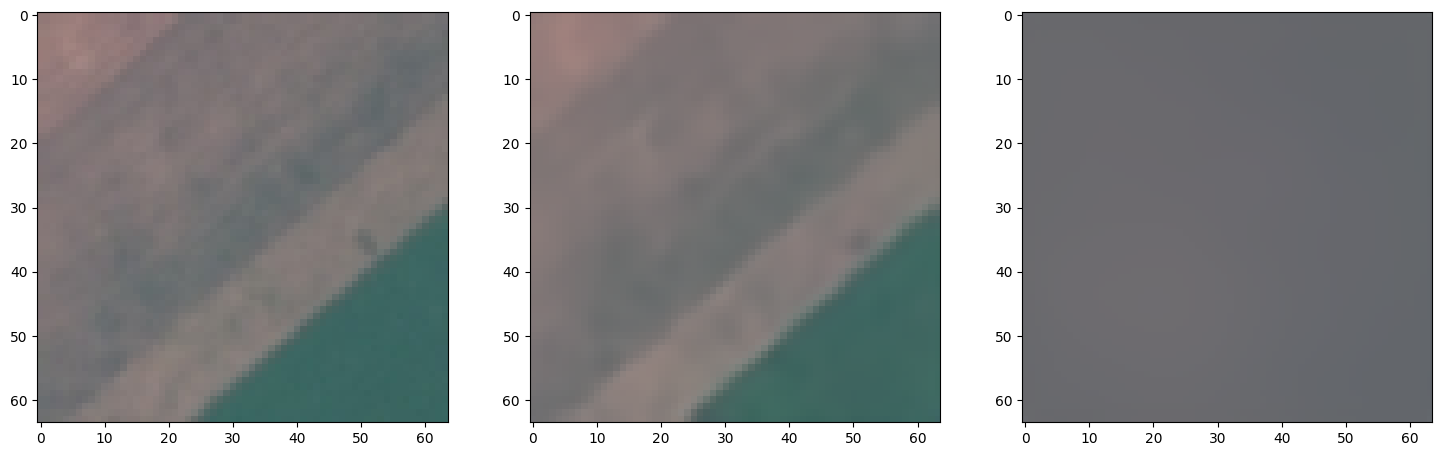

In [154]:
rand_imag = val_dataset[np.random.randint(len(val_dataset))][0]
with torch.no_grad():
    rec, rec_lat, _, _, _= model(rand_imag.unsqueeze(0).to(device))

rec_cpu = rec.squeeze(0).permute(1, 2, 0).cpu()
rec_lat_cpu = rec_lat.squeeze(0).permute(1, 2, 0).cpu()
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow((rand_imag.permute(1, 2, 0)  + 1) / 2)
ax[1].imshow((rec_cpu  + 1) / 2)
ax[2].imshow((rec_lat_cpu  + 1) / 2)

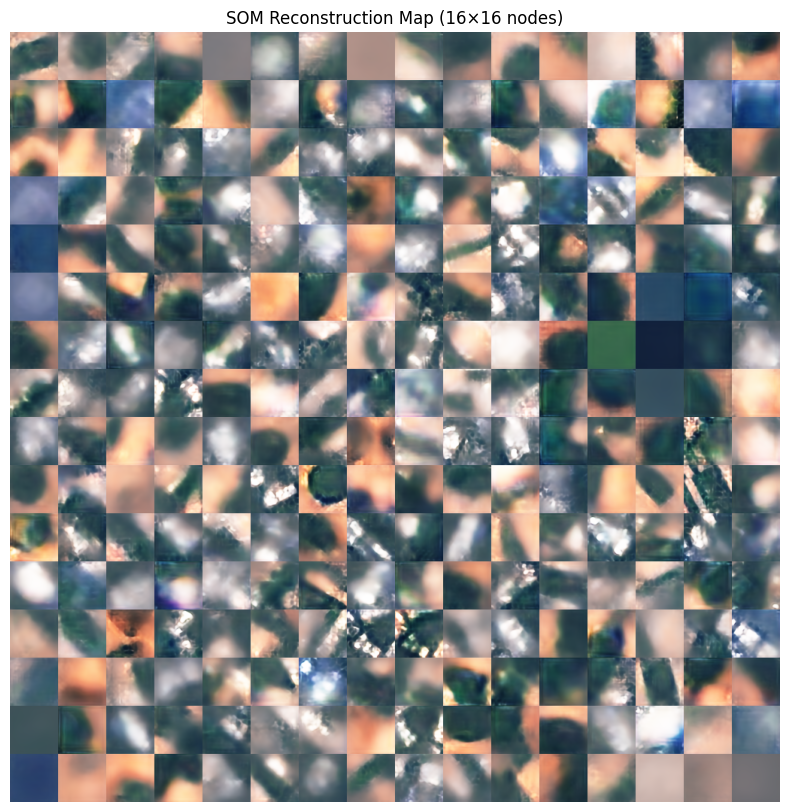

In [36]:
plot_som_reconstruction_map(model, figsize=(10, 10))

# Дотрен

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model,_ = load_model("./checkpoints_vae_sat/model_32x8x8latent_130epoch.pth", device=device)

/tmp/ipykernel_12416/1489735991.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


In [20]:
# Параметры обучения
batch_size = 128
epochs = 50
learning_rate = 5e-4
info_interval = 3

# Веса компонентов лосса
alpha = 0  # Commitment loss weight
beta = 1e-1  # SOM loss weight


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [ ]:
# Запуск обучения
history = train_som_vae(
    model=model, 
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    optimizer=optimizer, 
    device=device, 
    epochs=epochs, 
    batch_size=batch_size, 
    alpha=alpha, 
    beta=beta,
    info_interval=info_interval
)

In [ ]:
save_model(model, "./checkpoints_vae_sat/model_32x8x8latent_180epoch.pth")

# Проверка на MNIST

In [2]:

mnist_path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Dataset path:", mnist_path)
print(os.listdir(mnist_path))

Dataset path: /home/mihalko711/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2
['mnist_test.csv', 'mnist_train.csv']


## Датасет

In [3]:
class MNISTCsvDataset(Dataset):
    def __init__(self, root_dir, filename, transform=None):
        """
        Args:
            root_dir (string): Путь к папке, где лежит csv файл.
            filename (string): Имя файла (например, 'mnist_train.csv').
            transform (callable, optional): Опциональные трансформации (например, аугментация).
        """
        self.filepath = os.path.join(root_dir, filename)
        self.data = pl.read_csv(self.filepath)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        label = int(row[0, 0])
        
        pixels = row[0, 1:].to_numpy().astype(np.uint8)
        image = pixels.reshape(28, 28)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
            
        return image, label, label

In [4]:
# 2. Создаем трансформации (стандартный ToTensor делает HWC -> CHW и делит на 255)
data_transform = T.Compose([
    T.ToTensor(),   
    T.Normalize((0.5,), (.5,))   
])

# 3. Инициализируем датасеты
train_dataset = MNISTCsvDataset(
    root_dir=mnist_path, 
    filename='mnist_train.csv', 
    transform=data_transform
)

test_dataset = MNISTCsvDataset(
    root_dir=mnist_path, 
    filename='mnist_test.csv', 
    transform=data_transform
)

# 4. Создаем DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# Проверка: достанем один батч
images, labels, labels = next(iter(train_loader))
print(f"Размер батча картинок: {images.shape}") # Должно быть torch.Size([64, 1, 28, 28])
print(f"Размер батча меток: {labels.shape}")

Размер батча картинок: torch.Size([64, 1, 28, 28])
Размер батча меток: torch.Size([64])


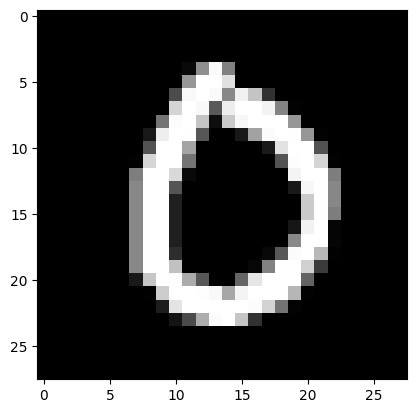

In [5]:
plt.imshow(train_dataset[np.random.randint(len(train_dataset))][0].permute(1, 2, 0), cmap='Greys_r')

## Модели

In [6]:
class GlobalSOMLayer(nn.Module):
    def __init__(self, grid_h, grid_w, channels, latent_h, latent_w):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.c, self.h, self.w = channels, latent_h, latent_w
        self.template_dim = channels * latent_h * latent_w
        self.embeddings = nn.Parameter(torch.randn(grid_h * grid_w, self.template_dim))

    def _compute_distances(self, z_e_flat, embeddings_flat):
        return torch.cdist(z_e_flat, embeddings_flat, p=2).pow(2)

    def forward(self, z_e):
        batch_size = z_e.size(0)
        z_e_flat = z_e.view(batch_size, -1)  # [B, D]
    
        # Считаем расстояния с учётом градиентов
        distances = self._compute_distances(z_e_flat, self.embeddings)  # [B, K]
    
        indices = torch.argmin(distances, dim=1)  # [B]
    
        z_q_flat = self.embeddings[indices]  # [B, D]
        z_q = z_q_flat.view(batch_size, self.c, self.h, self.w)
    
        return z_q, indices

    def get_neighbors(self, indices):
        # Логика поиска соседей по 2D сетке
        row = indices // self.grid_w
        col = indices % self.grid_w
        
        def get_idx(r, c):
            r = torch.clamp(r, 0, self.grid_h - 1)
            c = torch.clamp(c, 0, self.grid_w - 1)
            return r * self.grid_w + c

        return torch.stack([
            get_idx(row-1, col), get_idx(row+1, col), 
            get_idx(row, col-1), get_idx(row, col+1)
        ], dim=1)

In [7]:
batch_size = 10
vec_len = 10

a = torch.rand((batch_size, vec_len))
b = torch.rand((batch_size // 2, vec_len))

torch.cdist(a, b).argmin(dim=1)

tensor([4, 3, 2, 4, 1, 4, 4, 3, 4, 1])

In [8]:
class ResBlock(nn.Module):
    def __init__(self, channels, scale=0.1):
        super().__init__()
        self.scale = scale
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.scale * self.block(x)



class EuroSAT_GlobalSOM_Deep(nn.Module):
    def __init__(self, in_channels=1, grid_size=(16, 16), latent_dim=(32, 7, 7), num_classes=10):
        super().__init__()
        c_l, h_l, w_l = latent_dim # Теперь h_l, w_l должны быть (7, 7)

        # ---------------------
        # 1. ENCODER (28x28 -> 7x7)
        # ---------------------
        self.encoder = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14 -> 7x7
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Feature refinement at 7x7
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Channel projection to latent (128 -> c_l)
            nn.Conv2d(128, c_l, 1)
        )

        # ---------------------
        # 2. SOM LAYER
        # ---------------------
        # Убедитесь, что GlobalSOMLayer ожидает вход размера (c_l, 7, 7)
        self.som = GlobalSOMLayer(grid_size[0], grid_size[1], c_l, h_l, w_l)

        # ---------------------
        # 3. DECODER (7x7 -> 28x28)
        # ---------------------
        self.decoder = nn.Sequential(
            # Latent refinement
            nn.Conv2d(c_l, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(128),
        
            # 7x7 -> 14x14
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(64),
        
            # 14x14 -> 28x28
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(32),
        
            # Выходной слой
            nn.Conv2d(32, in_channels, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, indices = self.som(z_e)
        x_hat_e = self.decoder(z_e)
        x_hat_q = self.decoder(z_q)
        return x_hat_e, x_hat_q, z_e, z_q, indices

    def decode(self, z):
        return self.decoder(z)

## Loss

In [9]:
def som_vae_loss(
    x, x_hat_e, x_hat_q, z_e, z_q, indices, som_layer,
    alpha=1.0, beta=1.0
):
    # -------------------------
    # 1. Reconstruction loss (L2)
    # -------------------------
    l_rec_e = F.mse_loss(x_hat_e, x)
    l_rec_q = F.mse_loss(x_hat_q, x)
    l_reconstruction = l_rec_q + 0.25 * l_rec_e

    # -------------------------
    # 3. Commitment loss (L2)
    # -------------------------
    l_commitment = F.mse_loss(z_e, z_q)

    # -------------------------
    # 4. SOM neighbor loss (L2)
    # -------------------------
    neighbor_indices = som_layer.get_neighbors(indices)
    neighbors = som_layer.embeddings[neighbor_indices]
    z_e_target = z_e.detach().view(z_e.shape[0], -1).unsqueeze(1)
    l_som = torch.mean((neighbors - z_e_target) ** 2)

    # -------------------------
    # 5. Total loss
    # -------------------------
    total_loss = (
        l_reconstruction
        + alpha * l_commitment
        + beta * l_som
    )

    return (
        total_loss,
        l_reconstruction,
        l_commitment,
        l_som
    )

## Training Functions

### Map init func

In [10]:
def restart_som_with_data(model, train_loader, device):
    """
    Инициализация весов SOM реальными данными из первого батча
    """
    model.eval()
    with torch.no_grad():
        # Берем один батч
        images, _, _ = next(iter(train_loader))
        z_e = model.encoder(images.to(device)) # [B, C, H, W]
        z_e_flat = z_e.view(z_e.size(0), -1)   # [B, Dim]
        
        num_embeddings = model.som.embeddings.size(0)
        
        # Если батч меньше, чем число узлов, просто повторяем его
        indices = torch.arange(num_embeddings) % z_e_flat.size(0)
        initial_weights = z_e_flat[indices]
        
        # Прямое копирование в веса
        model.som.embeddings.data.copy_(initial_weights)
    print(f"Карта SOM инициализирована {num_embeddings} векторами из данных.")

### Default train func

In [11]:
def train_som_vae(model, train_dataset, val_dataset, optimizer, device,  info_interval=5,
                  epochs=50, batch_size=128, alpha=1.0, beta=1.0, gamma=1.0):
    """
    Обучение SOM-VAE модели
    """
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    
    # История обучения для визуализации
    history = {
        'train_loss': [], 'val_loss': [], 'nmi': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_losses = {'total': 0, 'rec': 0, 'comm': 0, 'som': 0}
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]")
        
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Прямой проход
            x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
            
            # Расчет лосса
            loss, l_rec, l_comm, l_som, = som_vae_loss(
                data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                alpha=alpha, beta=beta
            )
            
            loss.backward()
            optimizer.step()
            
            # Накопление лоссов
            train_losses['total'] += loss.item()
            train_losses['rec'] += l_rec.item()
            train_losses['comm'] += l_comm.item()
            train_losses['som'] += l_som.item()
            
            pbar.set_postfix({
                'L': f"{loss.item():.5f}",
                'Rec': f"{l_rec.item():.5f}",
                'Comm': f"{l_comm.item():.5f}",
                'som': f"{l_som.item():.5f}",
            })

        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()
        val_total_loss = 0
        all_indices = []
        all_labels = []
        
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)
                x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
                
                # Расчет лосса для валидации
                loss, _, _, _ = som_vae_loss(
                    data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                    alpha=alpha, beta=beta
                )
                
                val_total_loss += loss.item()

                all_indices.append(indices.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        # Расчет метрик
        flat_indices = np.concatenate(all_indices).ravel()
        flat_labels = np.concatenate(all_labels).ravel()
        current_nmi = normalized_mutual_info_score(flat_labels, flat_indices)
        
        # Сохранение истории
        history['train_loss'].append(train_losses['total'] / len(train_loader))
        history['val_loss'].append(val_total_loss / len(val_loader))
        history['nmi'].append(current_nmi)
        
        tqdm.write(f"Summary Epoch {epoch}:")
        tqdm.write(f"Train Loss: {history['train_loss'][-1]:.5f} | Val Loss: {history['val_loss'][-1]:.5f} | NMI: {current_nmi:.5f}")

        if epoch % info_interval == 0:
            plot_som_reconstruction_map(model)
    return history

## Visual

In [12]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

@torch.no_grad()
def plot_som_reconstruction_map(model, figsize=(15, 15), save_path=None):
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Извлекаем эмбеддинги
    # [K, D] -> [K, C, H, W]
    embeddings = model.som.embeddings
    z_q = embeddings.view(-1, model.som.c, model.som.h, model.som.w).to(device)
    
    # 2. Декодируем (на выходе [K, 1, 28, 28])
    reconstructions = model.decode(z_q).clamp(-1., 1.)
    
    # 3. Нормализуем [-1, 1] -> [0, 1]
    reconstructions = (reconstructions + 1.0) / 2.0
    
    # 4. Собираем сетку через torchvision
    # nrow — количество элементов в строке (grid_w)
    grid_w = model.som.grid_w
    grid_img = make_grid(reconstructions.cpu(), nrow=grid_w, padding=2, normalize=False)
    
    # 5. Отрисовка
    plt.figure(figsize=figsize)
    # Если канал 1 (ч/б), imshow все равно съест это через permute
    plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray' if model.som.c == 1 else None)
    plt.axis('off')
    plt.title(f'SOM Map: {model.som.grid_h}x{model.som.grid_w}')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

## Train

In [13]:
# Гиперпараметры модели
grid_size = (16, 16)           # Размер SOM сетки
latent_dim = (10, 7, 7)     # (channels, height, width) латентного представления
num_classes = 10

# Параметры обучения
batch_size = 64
epochs = 20
learning_rate = 5e-4
info_interval = 1

# Веса компонентов лосса
alpha = 1e-3  # Commitment loss weight
beta = 2e-2  # SOM loss weight

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Создание модели
model = EuroSAT_GlobalSOM_Deep(
    in_channels=1, 
    grid_size=grid_size, 
    latent_dim=latent_dim, 
    num_classes=num_classes
).to(device)


# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"SOM grid size: {grid_size[0]}x{grid_size[1]} = {grid_size[0] * grid_size[1]} nodes")
print(f"Latent dimension: {latent_dim}")

Using device: cuda
Model parameters: 726,059
SOM grid size: 16x16 = 256 nodes
Latent dimension: (10, 7, 7)


In [14]:
# Инициализация SOM весами из данных
train_loader_init = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
restart_som_with_data(model, train_loader_init, device)



print("Модель готова к обучению!")

Карта SOM инициализирована 256 векторами из данных.
Модель готова к обучению!


In [ ]:
# Запуск обучения
history = train_som_vae(
    model=model, 
    train_dataset=train_dataset, 
    val_dataset=test_dataset, 
    optimizer=optimizer, 
    device=device, 
    epochs=epochs, 
    batch_size=batch_size, 
    alpha=alpha, 
    beta=beta,
    info_interval=1
)

In [ ]:
# Запуск обучения
history = train_som_vae(
    model=model, 
    train_dataset=train_dataset, 
    val_dataset=test_dataset, 
    optimizer=optimizer, 
    device=device, 
    epochs=10, 
    batch_size=batch_size, 
    alpha=alpha, 
    beta=beta,
    info_interval=1
)

## Сохранение + загрузка

In [22]:
def save_model(model, path="model.pth"):
    torch.save(model.state_dict(), path)


def load_model(model_class, path="model.pth", device="cpu", **kwargs):
    model = model_class(**kwargs).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    return model

In [22]:
save_model(model, "./checkpoints_dirty_mnist/model_10x7x7latent_30epoch.pth")